# **Named Entity Recognition**

Named Entity Recognition (NER) is an information extraction subtask that seeks to locate and classify named entities in unstructured text into pre-defined categories such as person names, organizations, locations, time expressions, quantities, monetary values, percentages, etc.

**our objectif** is to identify and categorize key information elements in a text.

we can use it in **Search engines**(Improve the relevance of results by identifying important entities in queries and documents) , also in **Sentiment analysis**( To understand opinions expressed about specific products, people, or organizations) , or in **Recommendation systems**(Personalize content recommendations based on entities mentioned in a user's history) , **Question-answering:** ....

In this notebook , we focuses on applying NER using an encoder model specifically trained for French, it's **PantagrueLLM**.

## **WikiNER dataset** :

In [5]:
from datasets import load_dataset

ds = load_dataset("mnaguib/WikiNER", "fr")

The WikiNER (fr) dataset is ideal for French NER due to its extensive coverage from Wikipedia, providing diverse entities and significant data volume. Its linguistic relevance to the French-trained PantagrueLLM model ensures optimal performance.

In [6]:
print(len(ds["train"]))
print(len(ds["test"]))

119038
13398


In [7]:
# one example
ds["train"][0]

{'id': 'fr-doc7913-sent16',
 'words': ['Delhi',
  'a',
  'quatre',
  'villes',
  'satellites',
  'principales',
  'qui',
  'se',
  'trouvent',
  'en',
  'dehors',
  'du',
  'territoire',
  'national',
  'de',
  'Delhi',
  '.'],
 'ner_tags': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]}

In [8]:
# to pandas
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

In [9]:
df_train.sample(2)

,id,words,ner_tags
50521,fr-doc423-sent27,"[En, voyant, cela, ,, les, gardes, du, corps, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, ..."
105140,fr-doc4479-sent2,"[Toutes, décisions, régissant, la, stratégie, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, ..."


## **Analyse of data**

Distribution of Word Counts (df_train):
count    119038.000000
mean         26.143366
std          13.685830
min           1.000000
25%          17.000000
50%          23.000000
75%          33.000000
max         242.000000
Name: count, dtype: float64


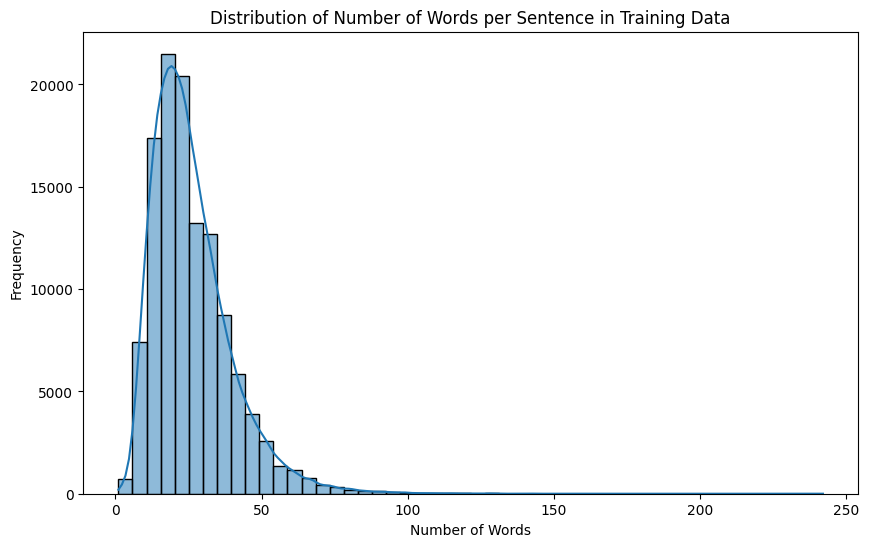

In [10]:
# Train dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df_train['count'] = df_train['words'].apply(len)

print("Distribution of Word Counts (df_train):")
print(df_train['count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_train['count'], bins=50, kde=True)
plt.title('Distribution of Number of Words per Sentence in Training Data')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

Distribution of Word Counts (df_test):
count    13398.000000
mean        26.331243
std         13.796530
min          1.000000
25%         17.000000
50%         24.000000
75%         33.000000
max        153.000000
Name: count, dtype: float64


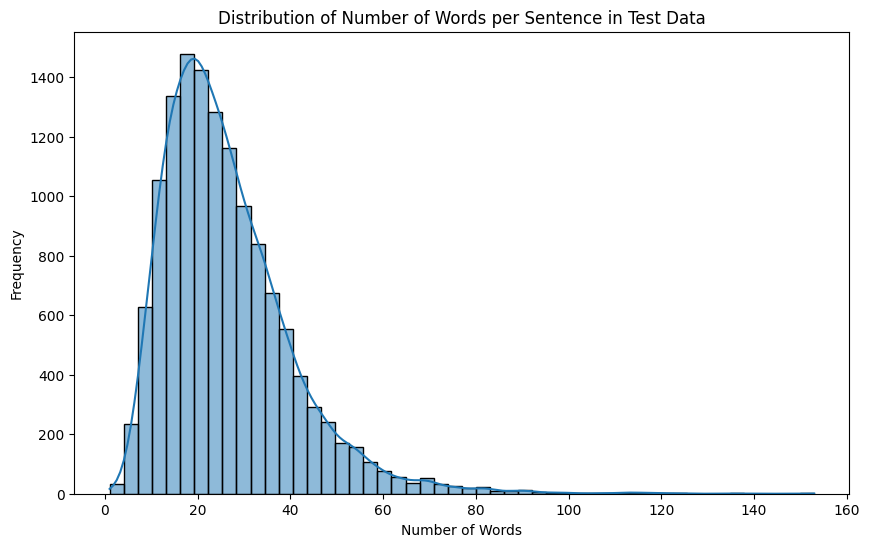

In [11]:
#Test dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df_test['count'] = df_test['words'].apply(len)

print("Distribution of Word Counts (df_test):")
print(df_test['count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_test['count'], bins=50, kde=True)
plt.title('Distribution of Number of Words per Sentence in Test Data')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [12]:
# We limit the number of sentences , by a filter
df_train = df_train[df_train['count'] < 50]
df_test = df_test[df_test['count'] <50]

In [13]:
# The new number of examples in train and test datasets
print(len(df_train))
print(len(df_test))

111803
12589


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset

train_ds = Dataset.from_pandas(df_train)   # len(df_train) = 111803
train_ds_sampled = train_ds.shuffle(seed=42).select(range(111000)) #111000

train_val = train_ds_sampled.train_test_split(test_size=0.1 ,seed=0)
df_train = train_val["train"].to_pandas()
df_val = train_val["test"].to_pandas()

test_hf_ds = Dataset.from_pandas(df_test)  #len(df_test) = 12589
test_ds_sampled = test_hf_ds.shuffle(seed=42).select(range(12500))
df_test = test_ds_sampled.to_pandas()

print(f"df_train_split shape: {df_train.shape}")
print(f"df_val_split shape: {df_val.shape}")
print(f"df_test_split shape: {df_test.shape}")

df_train_split shape: (99900, 5)
df_val_split shape: (11100, 5)
df_test_split shape: (12500, 5)


In [15]:
df_train.sample(4)

,id,words,ner_tags,count,__index_level_0__
12968,fr-doc4503-sent56,"[Une, petite, minorité, demande, l', asile, au...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 4, 0, 0, 1, 0]",15,83756
11361,fr-doc9064-sent2,"[La, panique, des, marchés, qui, a, suivi, a, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",25,34964
33193,fr-doc4511-sent10,"[Pendant, la, Seconde, Guerre, mondiale, ,, il...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",34,115692
39075,fr-doc9445-sent25,"[Il, est, nommé, en, 1826, conservateur, charg...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0]",15,118963


In [16]:
df_test.sample(4)

,id,words,ner_tags,count,__index_level_0__
9922,fr-doc11324-sent5,"[Les, marins, anglais, adoptèrent, ce, nom, en...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",18,10261
3801,fr-doc11988-sent44,"[L', escalade, continue, en, 2008, entre, le, ...","[0, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, 0, 0, 0]",15,5319
3088,fr-doc11404-sent12,"[Ce, programme, est, particulièrement, bien, r...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",26,112
3105,fr-doc11525-sent7,"[La, paroisse, d', Argol, était, paisible, .]","[0, 0, 0, 1, 0, 0, 0]",7,12976


In [17]:
df_val.sample(4)

,id,words,ner_tags,count,__index_level_0__
33,fr-doc5755-sent45,"[Au, début, de, son, règne, ,, Charlemagne, n'...","[0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]",16,17957
5080,fr-doc6818-sent5,"[À, cette, époque, ,, il, côtoie, Louis, Bouil...","[0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, ...",19,88728
4068,fr-doc7901-sent169,"[L', ANC, est, en, proie, aux, querelles, inte...","[0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",40,43656
737,fr-doc8098-sent30,"[Sa, résolution, est, confirmée, par, le, trai...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",14,10258


In [18]:
df_train.info()   #all values are non_null (ok)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99900 entries, 0 to 99899
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 99900 non-null  object
 1   words              99900 non-null  object
 2   ner_tags           99900 non-null  object
 3   count              99900 non-null  int64 
 4   __index_level_0__  99900 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 3.8+ MB


In [19]:
df_train.describe()  #more informations about trai_data

,count,__index_level_0__
count,99900.000000,99900.000000
mean,23.851962,59544.861812
std,10.069709,34358.821525
min,1.000000,0.000000
25%,16.000000,29817.750000
50%,23.000000,59584.000000
75%,31.000000,89270.250000
max,49.000000,119036.000000


## **Converting Word Lists to Sentences**

In [20]:
df_train['sentence'] = df_train['words'].str.join(" ")
df_test['sentence'] = df_test['words'].str.join(" ")
df_val['sentence'] = df_val['words'].str.join(" ")

print(df_train['sentence'][0])
print()
print(df_test['sentence'][0])
print()
print(df_val['sentence'][0])

En effet les travaux ont repris grâce à la pression américaine qui a aussi contribué à la révolte du Panamá envers cette même Colombie .

L' École supérieure d' économie de Prague , quant à elle , peut se targuer d' avoir vu passer sur ses bancs Václav Klaus , ancien ministre de l' économie , premier ministre puis président du pays , Jiří Paroubek et Miloš Zeman , ancien premier ministres socialistes .

A partir de 1949 , la victoire de Mao Zedong en Chine permet au Viêt-Minh de recevoir un équipement important venu de Chine , de l' Union soviétique et des autres pays du bloc communiste .


In [21]:
# we take one example from df_val (all others are the same)
df_val.head()  # we add a new colomne named "sentence"(ok)

,id,words,ner_tags,count,__index_level_0__,sentence
0,fr-doc9899-sent118,"[A, partir, de, 1949, ,, la, victoire, de, Mao...","[0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 4, ...",36,112940,"A partir de 1949 , la victoire de Mao Zedong e..."
1,fr-doc10852-sent34,"[La, Suisse, est, habituellement, divisée, en,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",11,63739,La Suisse est habituellement divisée en trois ...
2,fr-doc10778-sent20,"[En, 1977-1978, ,, ce, fut, Spassky, qui, remp...","[0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",32,76880,"En 1977-1978 , ce fut Spassky qui remplaça Fis..."
3,fr-doc8420-sent1,"[Il, est, nommé, en, l', honneur, de, l', astr...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0]",12,13656,Il est nommé en l' honneur de l' astronome Edw...
4,fr-doc9810-sent3,"[Aux, axiomes, de, la, logique, propositionnel...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",24,41565,Aux axiomes de la logique propositionnelle s' ...


# **PantagruelLLM model for text**

In [22]:
import torch
from transformers import AutoTokenizer, AutoModel

# Load the tokenizer and model
#model_name = "PantagrueLLM/text-base-wiki"
model_name = "PantagrueLLM/text-base-camtok-wiki"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

## **Named Entity Recognition (NER) standard**

We use the standard Named Entity Recognition (NER) tags, commonly used in dataset WikiNER.
* 'O' means Outside of an entity.
* 'LOC' means location (cities, countries, rivers, mountains...).
* 'PER' means person( people's first names, last names, or full name...).
* 'MISC' means Miscellaneous (nationalities, religions, political groups, events, artifacts, and abstract concepts).
* 'ORG' means organisation (companies, agencies, institutions, and groups).

In [23]:
label_list = ['O','LOC','PER','MISC','ORG']
print(f"label list: {label_list}")
num_labels = len(label_list)
print(f"Number of labels: {num_labels}")

label list: ['O', 'LOC', 'PER', 'MISC', 'ORG']
Number of labels: 5


# **The Model : Encoder + MLP**

In [24]:
import torch.nn as nn

class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLP, self).__init__()
    self.classifier_head = nn.Sequential(
       nn.Linear(input_dim, 1024),
       nn.ReLU(),
       nn.Dropout(0.2),
       nn.Linear(1024, 512),
       nn.ReLU(),
       nn.Dropout(0.1),
       nn.Linear(512, output_dim)    # Output directly num_labels logits = 5
    )

  def forward(self, x):
    return self.classifier_head(x)

In [25]:
import torch.nn as nn
from transformers import AutoModel, AutoConfig # Import AutoConfig

class PantagruelNER(nn.Module):
    def __init__(self, model_name, num_labels):
        super(PantagruelNER, self).__init__()
        # We Load config and ensure model_type is 'text'
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        if not hasattr(config, "model_type") or config.model_type != "text":
            config.model_type = "text"

        self.encoder = AutoModel.from_pretrained(model_name, config=config, trust_remote_code=True)
        print(self.encoder)

        # On gèle tout l'encodeur par défaut
        for param in self.encoder.parameters():
            param.requires_grad = False

        # On dégel les deux derniers blocs (10 et 11)
        # self.encoder.blocks contient la ModuleList de 12 blocs
        for i in range(10, 12):
          for param in self.encoder.blocks[i].parameters():
            param.requires_grad = True

        self.classifier = MLP(self.encoder.config.hidden_size, num_labels)
        self.num_labels = num_labels    # We store num_labels for loss calculation

    def forward(self, input_ids, attention_mask=None, labels=None):
        # encoder (PantagruelLLM)
        # Explicitly pass mode='text' for text inputs
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]    # We take the last hidden state

        # classifier(MLP)
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

model = PantagruelNER(model_name, num_labels=num_labels)

[ERROR] `padding_mask` is part of PantagruelUniForMaskedLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/PantagrueLLM/text_hyphen_base_hyphen_camtok_hyphen_wiki/e4cafe95e517714c359a4d04cb81532d882da1d6/modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForSequenceClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/PantagrueLLM/text_hyphen_base_hyphen_camtok_hyphen_wiki/e4cafe95e517714c359a4d04cb81532d882da1d6/modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForMultipleChoice.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/PantagrueLLM/text_hyphen_base_hyphen_camtok_hyphen_wiki/e4cafe95e517714c359a4d04cb81532d882da1d6/mod

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

PantagruelUniModel LOAD REPORT from: PantagrueLLM/text-base-camtok-wiki
Key                      | Status  | 
-------------------------+---------+-
text_pooler.dense.weight | MISSING | 
text_pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PantagruelUniModel(
  (modality_encoders): ModuleDict(
    (TEXT): TextEncoder(
      (local_encoder): TextLocalEncoder(
        (dropout_module): Dropout(p=0.1, inplace=False)
        (embed_tokens): Embedding(32005, 768, padding_idx=1)
        (embed_positions): LearnedPositionalEmbedding(514, 768, padding_idx=1)
        (layernorm_embedding): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
      (project_features): Identity()
      (context_encoder): BlockEncoder(
        (blocks): ModuleList()
        (dropout): Dropout(p=0.0, inplace=True)
      )
    )
  )
  (dropout_input): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x AltBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): AltAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-05, 

In [26]:
!pip install torch==2.3.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torchtext==0.18.0

Looking in indexes: https://download.pytorch.org/whl/cu121


In [27]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True
    )

    all_labels = []
    for i, ner_tags_original in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word_idx = None

        for word_idx in word_ids:
            if word_idx is None:
                # [CLS], [SEP] ou padding -> -100
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # C'est le début d'un nouveau mot -> on prend le vrai tag
                label_ids.append(ner_tags_original[word_idx])
            else:
                # C'est un morceau de mot (ex: ##ïdo) -> -100
                label_ids.append(-100)
            previous_word_idx = word_idx

        all_labels.append(label_ids)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

In [28]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# On prépare les datasets
train_dataset = Dataset.from_pandas(df_train).map(tokenize_and_align_labels, batched=True)
val_dataset = Dataset.from_pandas(df_val).map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/99900 [00:00<?, ? examples/s]

Map:   0%|          | 0/11100 [00:00<?, ? examples/s]

## **Training the Model**

In [29]:
!pip install evaluate
!pip install seqeval

In [30]:
import numpy as np
import evaluate

metric = evaluate.load("seqeval") # We load the metric

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # On supprime les indices ignorés (-100)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
from transformers import TrainingArguments, Trainer

# Define training arguments
training_args = TrainingArguments(
    output_dir="./ner_pantagruel_results",  # Output directory
    eval_strategy="epoch",                # Evaluation strategy
    learning_rate=5e-5,                    # Learning rate
    per_device_train_batch_size=16,        # Reduced batch size
    per_device_eval_batch_size=16,         # Reduced batch size for evaluation
    num_train_epochs=12,                    # Number of training epochs
    weight_decay=0.02,                     # Strength of weight decay
    logging_dir='./ner_pantagruel_logs',   # Directory for storing logs
    logging_steps=500,
    save_strategy="epoch",                 # Save checkpoint every epoch
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",     # Metric to use to compare models
    greater_is_better=False                # Lower eval_loss is better
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics

)

# Train the model
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.256250,0.224439,0.422959,0.466341,0.443592,0.934533
2,0.213315,0.180116,0.503867,0.583011,0.540558,0.946100
3,0.183684,0.158612,0.547045,0.644431,0.591758,0.952509
4,0.166319,0.146739,0.564021,0.696088,0.623134,0.955612
5,0.148736,0.136402,0.580629,0.721782,0.643557,0.957837
6,0.136966,0.129071,0.601506,0.736560,0.662217,0.959438
7,0.127206,0.122466,0.620321,0.754932,0.681038,0.961469
8,0.117952,0.113614,0.648201,0.760694,0.699956,0.964001
9,0.109683,0.111999,0.650443,0.770999,0.705609,0.964269


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: Use

### **Training and Evaluation Metrics Evolution**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract training and evaluation logs
log_history = trainer.state.log_history

train_logs = [entry for entry in log_history if 'loss' in entry and 'learning_rate' in entry]
eval_logs = [entry for entry in log_history if 'eval_loss' in entry]

# Prepare data for plotting
train_epochs = [log['epoch'] for log in train_logs]
train_losses = [log['loss'] for log in train_logs]

eval_epochs = [log['epoch'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]
eval_precision = [log['eval_precision'] for log in eval_logs]
eval_recall = [log['eval_recall'] for log in eval_logs]
eval_f1 = [log['eval_f1'] for log in eval_logs]
eval_accuracy = [log['eval_accuracy'] for log in eval_logs]

# Plotting function
def plot_metrics(train_data, eval_data, metric_name, ylabel):
    plt.figure(figsize=(10, 6))
    plt.plot(train_epochs, train_data, label=f'Training {metric_name}', marker='o', linestyle='-', markersize=4)
    plt.plot(eval_epochs, eval_data, label=f'Validation {metric_name}', marker='x', linestyle='--', markersize=4)
    plt.title(f'{metric_name} Evolution over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Loss
plot_metrics(train_losses, eval_losses, 'Loss', 'Loss Value')

# Plot Precision, Recall, F1, Accuracy (only for evaluation, as these are typically computed at epoch end for eval)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(eval_epochs, eval_precision, label='Validation Precision', marker='x', linestyle='--', markersize=4)
plt.title('Precision Evolution')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(eval_epochs, eval_recall, label='Validation Recall', marker='x', linestyle='--', markersize=4)
plt.title('Recall Evolution')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(eval_epochs, eval_f1, label='Validation F1 Score', marker='x', linestyle='--', markersize=4)
plt.title('F1 Score Evolution')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(eval_epochs, eval_accuracy, label='Validation Accuracy', marker='x', linestyle='--', markersize=4)
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'trainer' is not defined

### Plotting Metrics from Provided Data

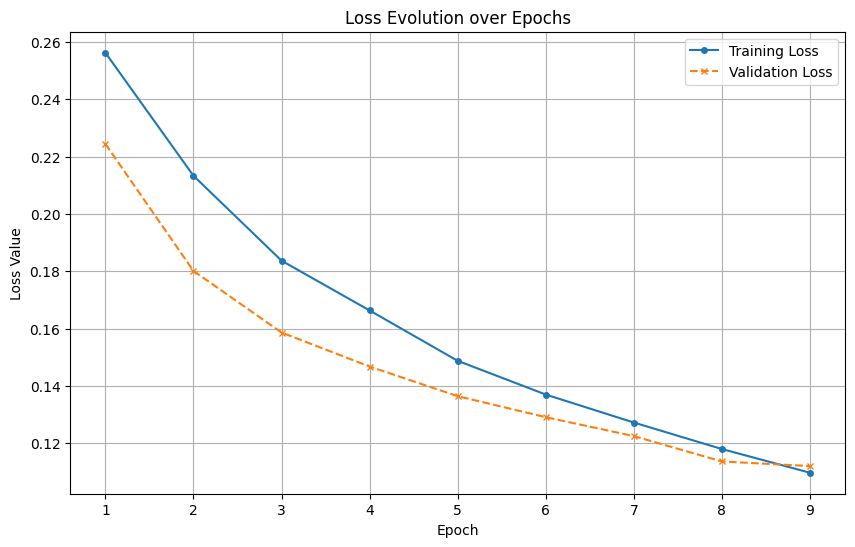

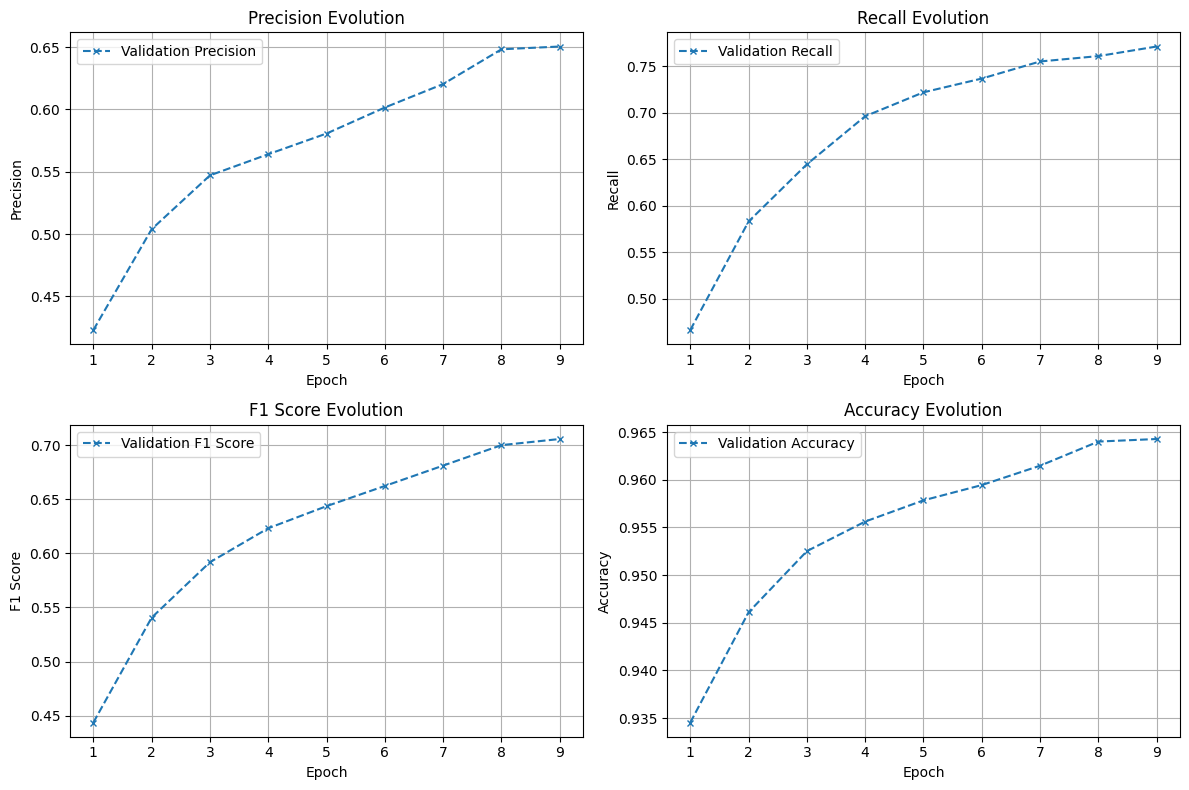

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Data provided by the user
metrics_data = {
    'Epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Training Loss': [0.256250, 0.213315, 0.183684, 0.166319, 0.148736, 0.136966, 0.127206, 0.117952, 0.109683],
    'Validation Loss': [0.224439, 0.180116, 0.158612, 0.146739, 0.136402, 0.129071, 0.122466, 0.113614, 0.111999],
    'Precision': [0.422959, 0.503867, 0.547045, 0.564021, 0.580629, 0.601506, 0.620321, 0.648201, 0.650443],
    'Recall': [0.466341, 0.583011, 0.644431, 0.696088, 0.721782, 0.736560, 0.754932, 0.760694, 0.770999],
    'F1': [0.443592, 0.540558, 0.591758, 0.623134, 0.643557, 0.662217, 0.681038, 0.699956, 0.705609],
    'Accuracy': [0.934533, 0.946100, 0.952509, 0.955612, 0.957837, 0.959438, 0.961469, 0.964001, 0.964269]
}

df_metrics = pd.DataFrame(metrics_data)

# Prepare data for plotting
train_epochs = df_metrics['Epoch'].tolist()
train_losses = df_metrics['Training Loss'].tolist()

eval_epochs = df_metrics['Epoch'].tolist()
eval_losses = df_metrics['Validation Loss'].tolist()
eval_precision = df_metrics['Precision'].tolist()
eval_recall = df_metrics['Recall'].tolist()
eval_f1 = df_metrics['F1'].tolist()
eval_accuracy = df_metrics['Accuracy'].tolist()

# Plotting function
def plot_combined_metrics(epochs_train, data_train, epochs_eval, data_eval, metric_name, ylabel):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_train, data_train, label=f'Training {metric_name}', marker='o', linestyle='-', markersize=4)
    plt.plot(epochs_eval, data_eval, label=f'Validation {metric_name}', marker='x', linestyle='--', markersize=4)
    plt.title(f'{metric_name} Evolution over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Loss
plot_combined_metrics(train_epochs, train_losses, eval_epochs, eval_losses, 'Loss', 'Loss Value')

# Plot other evaluation metrics (Precision, Recall, F1, Accuracy)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(eval_epochs, eval_precision, label='Validation Precision', marker='x', linestyle='--', markersize=4)
plt.title('Precision Evolution')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(eval_epochs, eval_recall, label='Validation Recall', marker='x', linestyle='--', markersize=4)
plt.title('Recall Evolution')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(eval_epochs, eval_f1, label='Validation F1 Score', marker='x', linestyle='--', markersize=4)
plt.title('F1 Score Evolution')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(eval_epochs, eval_accuracy, label='Validation Accuracy', marker='x', linestyle='--', markersize=4)
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [1]:
from datasets import Dataset
test_dataset = Dataset.from_pandas(df_test).map(tokenize_and_align_labels, batched=True)
final_metrics = trainer.evaluate(test_dataset)

print(f"Final Résults for this model : {final_metrics}")

NameError: name 'Dataset' is not defined

### **Final Test Data Metrics**

In [ ]:
# Display the final metrics for the test set
print("Final Evaluation Metrics on Test Set:")
for key, value in final_metrics.items():
    if key.startswith('eval_'):
        print(f"- {key[5:].replace('_', ' ').title()}: {value:.4f}")